# Step 13: Demand-Type-Specific Exploratory Data Analysis

This step examines how the selected smooth, erratic, intermittent, and lumpy series differ in sparsity, sales volume, category composition, store representation, SNAP response, event response, and price behaviour.

The modelling subset contains 800 item-store series, with 200 series from each demand type. Because the subset is balanced, each demand type represents 25.0% of the modelling data. This does not reproduce the original M5 population distribution, where intermittent demand represents 75.681% of all series.

All findings in this step are therefore reported separately by demand type.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import pyarrow.parquet as pq

np.random.seed(42)

project_root = Path("..")

processed_data_path = project_root / "data" / "processed"
subset_data_path = project_root / "data" / "subset"

figures_path = project_root / "outputs" / "figures" / "step13"
tables_path = project_root / "outputs" / "tables" / "step13"

figures_path.mkdir(parents=True, exist_ok=True)
tables_path.mkdir(parents=True, exist_ok=True)

subset_file = subset_data_path / "selected_m5_data.parquet"
selected_series_file = subset_data_path / "selected_series.csv"

print("Subset file:", subset_file)
print("Figures folder:", figures_path)
print("Tables folder:", tables_path)

Subset file: ..\data\subset\selected_m5_data.parquet
Figures folder: ..\outputs\figures\step13
Tables folder: ..\outputs\tables\step13


In [2]:
parquet_metadata = pq.ParquetFile(subset_file)

saved_file_size_mb = (
    subset_file.stat().st_size / (1024 ** 2)
)

print("Saved file size MB:", round(saved_file_size_mb, 3))
print(
    "Parquet metadata rows:",
    parquet_metadata.metadata.num_rows
)
print(
    "Parquet metadata columns:",
    parquet_metadata.metadata.num_columns
)
print(
    "Parquet row groups:",
    parquet_metadata.metadata.num_row_groups
)

Saved file size MB: 0.921
Parquet metadata rows: 1552800
Parquet metadata columns: 24
Parquet row groups: 2


In [3]:
selected_m5_data = pd.read_parquet(subset_file)

selected_series = pd.read_csv(
    selected_series_file
)

print("Selected M5 shape:", selected_m5_data.shape)
print("Selected series shape:", selected_series.shape)
print()
print(selected_m5_data.dtypes)

Selected M5 shape: (1552800, 24)
Selected series shape: (800, 13)

id                      object
item_id                 object
dept_id                 object
cat_id                  object
store_id                object
state_id                object
d                       object
sales                    int64
date            datetime64[ns]
wm_yr_wk                 int64
weekday                 object
wday                     int64
month                    int64
year                     int64
event_name_1            object
event_type_1            object
event_name_2            object
event_type_2            object
snap                     int64
sell_price             float32
demand_type           category
ADI                    float64
CV2                    float64
zero_rate              float64
dtype: object


In [4]:
selected_m5_data["date"] = pd.to_datetime(
    selected_m5_data["date"]
)

demand_type_order = [
    "smooth",
    "erratic",
    "intermittent",
    "lumpy"
]

selected_m5_data["demand_type"] = pd.Categorical(
    selected_m5_data["demand_type"],
    categories=demand_type_order,
    ordered=True
)

selected_series["demand_type"] = pd.Categorical(
    selected_series["demand_type"],
    categories=demand_type_order,
    ordered=True
)

rows_per_series = (
    selected_m5_data
    .groupby("id", observed=True)
    .size()
)

duplicate_id_dates = selected_m5_data.duplicated(
    subset=["id", "date"]
).sum()

print("Rows:", len(selected_m5_data))
print("Unique series:", selected_m5_data["id"].nunique())
print("Minimum rows per series:", rows_per_series.min())
print("Maximum rows per series:", rows_per_series.max())
print("Duplicate id-date rows:", duplicate_id_dates)

print(
    "Missing demand types:",
    selected_m5_data["demand_type"].isna().sum()
)

print(
    "Date range:",
    selected_m5_data["date"].min(),
    "to",
    selected_m5_data["date"].max()
)

print()
print("Series by demand type:")
print(
    selected_series["demand_type"]
    .value_counts(sort=False)
)

Rows: 1552800
Unique series: 800
Minimum rows per series: 1941
Maximum rows per series: 1941
Duplicate id-date rows: 0
Missing demand types: 0
Date range: 2011-01-29 00:00:00 to 2016-05-22 00:00:00

Series by demand type:
demand_type
smooth          200
erratic         200
intermittent    200
lumpy           200
Name: count, dtype: int64


In [5]:
selected_m5_data = selected_m5_data.sort_values(
    ["id", "date"]
).reset_index(drop=True)

selected_m5_data["has_event"] = (
    selected_m5_data["event_name_1"].notna()
    | selected_m5_data["event_name_2"].notna()
)

selected_m5_data["is_weekend"] = (
    selected_m5_data["weekday"]
    .isin(["Saturday", "Sunday"])
)

selected_m5_data["price_available"] = (
    selected_m5_data["sell_price"].notna()
)

print(
    "Event-day rows:",
    selected_m5_data["has_event"].sum()
)

print(
    "SNAP rows:",
    selected_m5_data["snap"].sum()
)

print(
    "Rows with available prices:",
    selected_m5_data["price_available"].sum()
)

print(
    "Rows with missing prices:",
    selected_m5_data["sell_price"].isna().sum()
)

Event-day rows: 126400
SNAP rows: 512000
Rows with available prices: 1394908
Rows with missing prices: 157892


In [6]:
full_classification = pd.read_csv(
    processed_data_path / "demand_classification.csv"
)

full_classification["demand_type"] = pd.Categorical(
    full_classification["demand_type"],
    categories=demand_type_order,
    ordered=True
)

print("Full classification rows:", len(full_classification))

Full classification rows: 30490


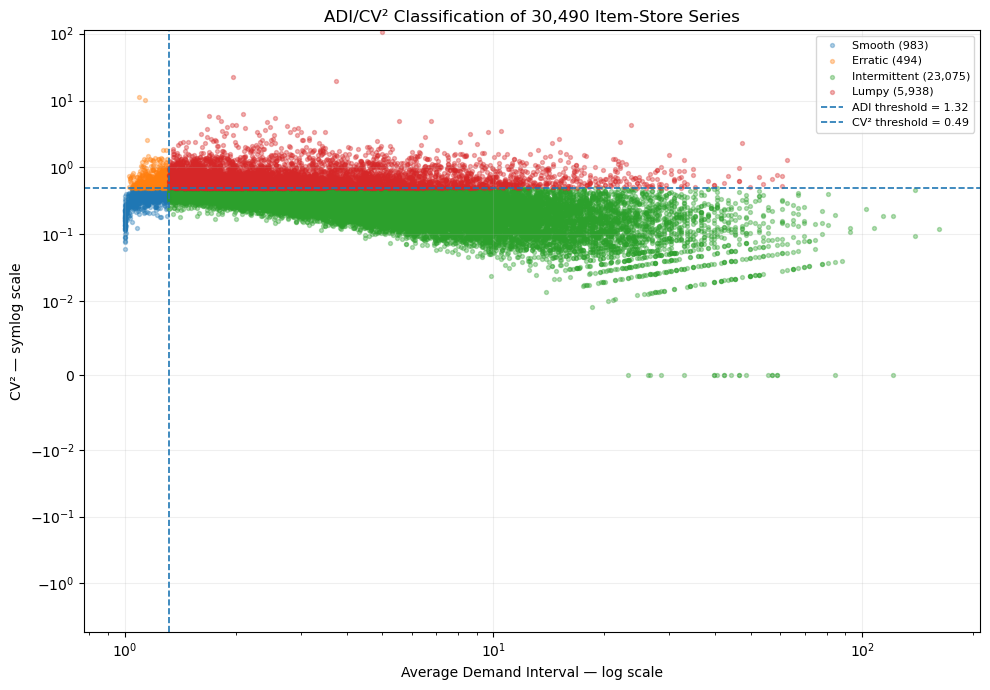

Saved: ..\outputs\figures\step13\step13_adi_cv2_classification.png


In [7]:
fig, ax = plt.subplots(figsize=(10, 7))

for demand_type in demand_type_order:
    group = full_classification.loc[
        full_classification["demand_type"] == demand_type
    ]
    
    ax.scatter(
        group["ADI"],
        group["CV2"],
        s=8,
        alpha=0.35,
        label=f"{demand_type.title()} ({len(group):,})"
    )

ax.axvline(
    1.32,
    linestyle="--",
    linewidth=1.2,
    label="ADI threshold = 1.32"
)

ax.axhline(
    0.49,
    linestyle="--",
    linewidth=1.2,
    label="CV² threshold = 0.49"
)

ax.set_xscale("log")
ax.set_yscale(
    "symlog",
    linthresh=0.01
)

ax.set_xlabel("Average Demand Interval — log scale")
ax.set_ylabel("CV² — symlog scale")
ax.set_title("ADI/CV² Classification of 30,490 Item-Store Series")

ax.legend(
    loc="best",
    fontsize=8
)

ax.grid(
    alpha=0.2
)

figure_file = (
    figures_path
    / "step13_adi_cv2_classification.png"
)

fig.tight_layout()

fig.savefig(
    figure_file,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:", figure_file)

**Figure 13.1:** ADI/CV² classification of 30,490 item-store series.

In [8]:
demand_type_profile = (
    selected_series
    .groupby("demand_type", observed=True)
    .agg(
        series_count=("id", "count"),
        mean_ADI=("ADI", "mean"),
        median_ADI=("ADI", "median"),
        mean_CV2=("CV2", "mean"),
        median_CV2=("CV2", "median"),
        mean_zero_rate=("zero_rate", "mean"),
        median_zero_rate=("zero_rate", "median"),
        mean_total_sales=("total_sales", "mean"),
        median_total_sales=("total_sales", "median"),
        mean_non_zero_days=("non_zero_days", "mean"),
        median_non_zero_days=("non_zero_days", "median")
    )
    .reindex(demand_type_order)
    .round(3)
)

demand_type_profile

,series_count,mean_ADI,median_ADI,mean_CV2,median_CV2,mean_zero_rate,median_zero_rate,mean_total_sales,median_total_sales,mean_non_zero_days,median_non_zero_days
demand_type,,,,,,,,,,,
smooth,200,1.176,1.190,0.376,0.387,14.382,15.945,12416.935,7399.0,1661.845,1631.5
erratic,200,1.207,1.217,0.728,0.613,16.827,17.826,13049.885,10928.5,1614.395,1595.0
intermittent,200,7.234,4.125,0.286,0.288,72.436,75.760,1291.970,673.5,535.025,470.5
lumpy,200,4.165,2.399,0.721,0.599,59.889,58.320,2851.305,1977.5,778.555,809.0


In [9]:
profile_file = (
    tables_path
    / "step13_demand_type_profile.csv"
)

demand_type_profile.to_csv(profile_file)

print("Saved:", profile_file)

Saved: ..\outputs\tables\step13\step13_demand_type_profile.csv


C:\Users\gamec\AppData\Local\Temp\ipykernel_40472\2784163060.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(


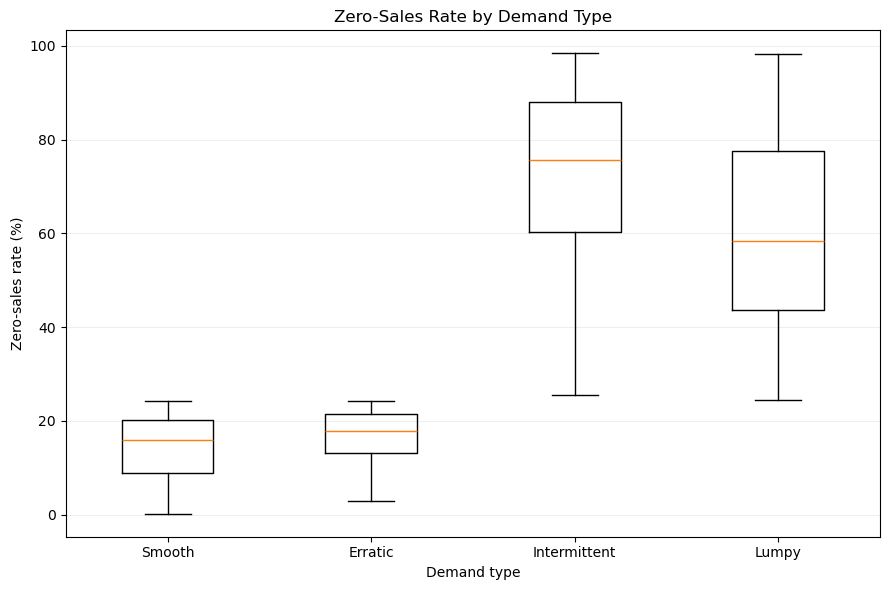

Saved: ..\outputs\figures\step13\step13_zero_rate_by_demand_type.png


In [10]:
zero_rate_data = [
    selected_series.loc[
        selected_series["demand_type"] == demand_type,
        "zero_rate"
    ].to_numpy()
    for demand_type in demand_type_order
]

fig, ax = plt.subplots(figsize=(9, 6))

ax.boxplot(
    zero_rate_data,
    labels=[
        demand_type.title()
        for demand_type in demand_type_order
    ],
    showfliers=False
)

ax.set_xlabel("Demand type")
ax.set_ylabel("Zero-sales rate (%)")
ax.set_title("Zero-Sales Rate by Demand Type")
ax.grid(
    axis="y",
    alpha=0.2
)

figure_file = (
    figures_path
    / "step13_zero_rate_by_demand_type.png"
)

fig.tight_layout()

fig.savefig(
    figure_file,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:", figure_file)

**Figure 13.2:** Zero-sales rate across the four demand types.

In [11]:
series_sales = (
    selected_m5_data
    .groupby(
        ["id", "demand_type"],
        observed=True,
        as_index=False
    )
    .agg(
        total_sales=("sales", "sum"),
        mean_daily_sales=("sales", "mean"),
        non_zero_days=(
            "sales",
            lambda values: (values > 0).sum()
        )
    )
)

series_sales["mean_non_zero_demand"] = np.divide(
    series_sales["total_sales"],
    series_sales["non_zero_days"],
    out=np.full(
        len(series_sales),
        np.nan,
        dtype=float
    ),
    where=series_sales["non_zero_days"] > 0
)

sales_volume_summary = (
    series_sales
    .groupby("demand_type", observed=True)
    .agg(
        series_count=("id", "count"),
        total_sales=("total_sales", "sum"),
        mean_total_sales_per_series=("total_sales", "mean"),
        median_total_sales_per_series=("total_sales", "median"),
        mean_daily_sales_per_series=("mean_daily_sales", "mean"),
        median_daily_sales_per_series=("mean_daily_sales", "median"),
        mean_non_zero_demand=("mean_non_zero_demand", "mean"),
        median_non_zero_demand=("mean_non_zero_demand", "median")
    )
    .reindex(demand_type_order)
    .round(3)
)

sales_volume_summary

,series_count,total_sales,mean_total_sales_per_series,median_total_sales_per_series,mean_daily_sales_per_series,median_daily_sales_per_series,mean_non_zero_demand,median_non_zero_demand
demand_type,,,,,,,,
smooth,200,2483387,12416.935,7399.0,6.397,3.812,7.154,4.453
erratic,200,2609977,13049.885,10928.5,6.723,5.630,8.022,6.809
intermittent,200,258394,1291.970,673.5,0.666,0.347,1.916,1.476
lumpy,200,570261,2851.305,1977.5,1.469,1.019,3.166,2.463


In [12]:
sales_summary_file = (
    tables_path
    / "step13_sales_volume_by_demand_type.csv"
)

sales_volume_summary.to_csv(
    sales_summary_file
)

print("Saved:", sales_summary_file)

Saved: ..\outputs\tables\step13\step13_sales_volume_by_demand_type.csv


C:\Users\gamec\AppData\Local\Temp\ipykernel_40472\1301780106.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(


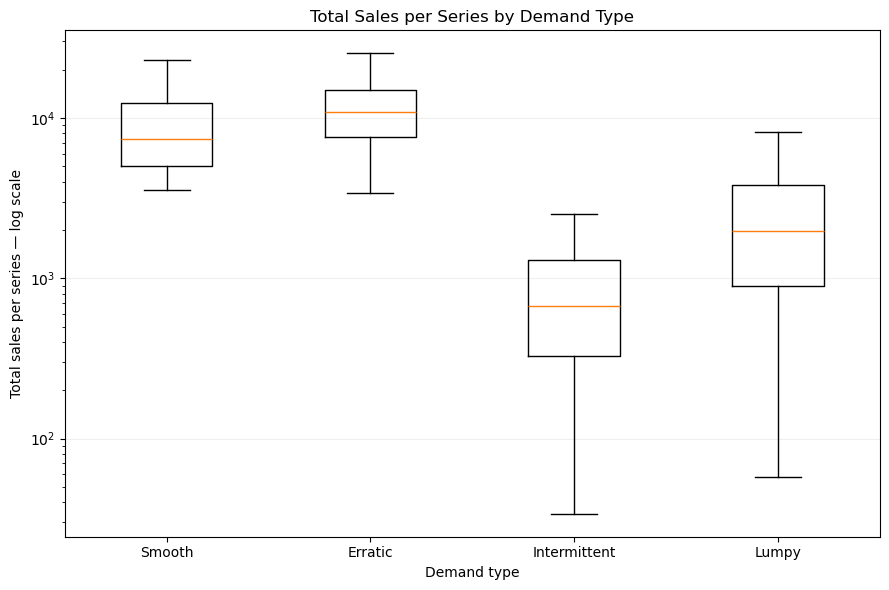

Saved: ..\outputs\figures\step13\step13_total_sales_by_demand_type.png


In [13]:
sales_plot_data = [
    series_sales.loc[
        series_sales["demand_type"] == demand_type,
        "total_sales"
    ].to_numpy()
    for demand_type in demand_type_order
]

fig, ax = plt.subplots(figsize=(9, 6))

ax.boxplot(
    sales_plot_data,
    labels=[
        demand_type.title()
        for demand_type in demand_type_order
    ],
    showfliers=False
)

ax.set_yscale("log")
ax.set_xlabel("Demand type")
ax.set_ylabel("Total sales per series — log scale")
ax.set_title("Total Sales per Series by Demand Type")
ax.grid(
    axis="y",
    alpha=0.2
)

figure_file = (
    figures_path
    / "step13_total_sales_by_demand_type.png"
)

fig.tight_layout()

fig.savefig(
    figure_file,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:", figure_file)

**Figure 13.3:** Total sales per selected series by demand type.

In [14]:
category_counts = pd.crosstab(
    selected_series["demand_type"],
    selected_series["cat_id"]
).reindex(demand_type_order)

category_percentages = (
    pd.crosstab(
        selected_series["demand_type"],
        selected_series["cat_id"],
        normalize="index"
    )
    .reindex(demand_type_order)
    * 100
).round(2)

category_counts

cat_id,FOODS,HOBBIES,HOUSEHOLD
demand_type,,,
smooth,134,14,52
erratic,141,20,39
intermittent,80,42,78
lumpy,128,40,32


In [15]:
category_percentages

cat_id,FOODS,HOBBIES,HOUSEHOLD
demand_type,,,
smooth,67.0,7.0,26.0
erratic,70.5,10.0,19.5
intermittent,40.0,21.0,39.0
lumpy,64.0,20.0,16.0


In [16]:
category_counts.to_csv(
    tables_path
    / "step13_category_counts_by_demand_type.csv"
)

category_percentages.to_csv(
    tables_path
    / "step13_category_percentages_by_demand_type.csv"
)

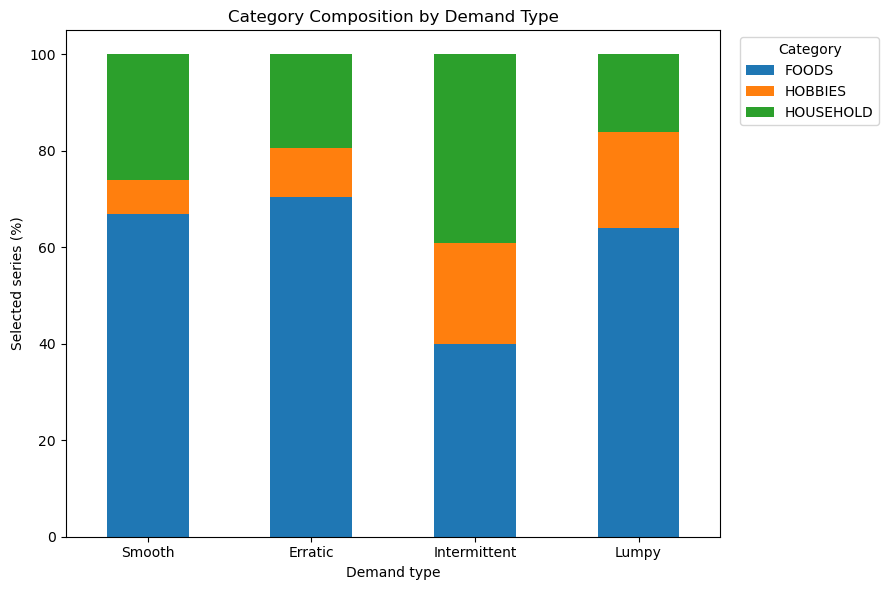

Saved: ..\outputs\figures\step13\step13_category_mix_by_demand_type.png


In [17]:
fig, ax = plt.subplots(figsize=(9, 6))

category_percentages.plot(
    kind="bar",
    stacked=True,
    ax=ax
)

ax.set_xlabel("Demand type")
ax.set_ylabel("Selected series (%)")
ax.set_title("Category Composition by Demand Type")
ax.legend(
    title="Category",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

ax.set_xticklabels(
    [
        demand_type.title()
        for demand_type in demand_type_order
    ],
    rotation=0
)

figure_file = (
    figures_path
    / "step13_category_mix_by_demand_type.png"
)

fig.tight_layout()

fig.savefig(
    figure_file,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:", figure_file)

**Figure 13.4:** Category composition of the balanced subset.

In [18]:
store_counts = pd.crosstab(
    selected_series["demand_type"],
    selected_series["store_id"]
).reindex(demand_type_order)

store_percentages = (
    pd.crosstab(
        selected_series["demand_type"],
        selected_series["store_id"],
        normalize="index"
    )
    .reindex(demand_type_order)
    * 100
).round(2)

store_counts

store_id,CA_1,CA_2,CA_3,CA_4,TX_1,TX_2,TX_3,WI_1,WI_2,WI_3
demand_type,,,,,,,,,,
smooth,27,16,42,15,18,22,19,14,12,15
erratic,18,21,34,10,22,24,19,17,15,20
intermittent,20,19,18,22,20,19,20,21,21,20
lumpy,20,24,23,15,20,23,19,16,20,20


In [19]:
store_counts.to_csv(
    tables_path
    / "step13_store_counts_by_demand_type.csv"
)

store_percentages.to_csv(
    tables_path
    / "step13_store_percentages_by_demand_type.csv"
)

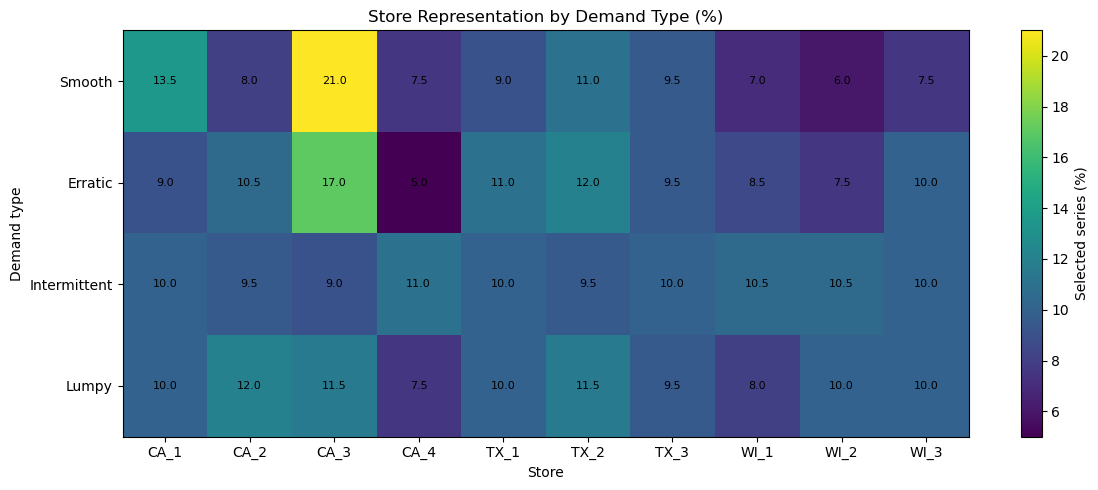

Saved: ..\outputs\figures\step13\step13_store_mix_by_demand_type.png


In [20]:
fig, ax = plt.subplots(figsize=(12, 5))

image = ax.imshow(
    store_percentages.to_numpy(),
    aspect="auto"
)

ax.set_xticks(
    range(len(store_percentages.columns))
)

ax.set_xticklabels(
    store_percentages.columns
)

ax.set_yticks(
    range(len(store_percentages.index))
)

ax.set_yticklabels(
    [
        demand_type.title()
        for demand_type in store_percentages.index
    ]
)

for row_index in range(store_percentages.shape[0]):
    for column_index in range(store_percentages.shape[1]):
        value = store_percentages.iloc[
            row_index,
            column_index
        ]
        
        ax.text(
            column_index,
            row_index,
            f"{value:.1f}",
            ha="center",
            va="center",
            fontsize=8
        )

ax.set_xlabel("Store")
ax.set_ylabel("Demand type")
ax.set_title("Store Representation by Demand Type (%)")

fig.colorbar(
    image,
    ax=ax,
    label="Selected series (%)"
)

figure_file = (
    figures_path
    / "step13_store_mix_by_demand_type.png"
)

fig.tight_layout()

fig.savefig(
    figure_file,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:", figure_file)

**Figure 13.5:** Store representation within each demand type.

In [21]:
snap_series_effect = (
    selected_m5_data
    .groupby(
        ["id", "demand_type", "snap"],
        observed=True
    )["sales"]
    .mean()
    .unstack("snap")
    .reindex(columns=[0, 1])
    .rename(
        columns={
            0: "mean_non_snap_sales",
            1: "mean_snap_sales"
        }
    )
    .reset_index()
)

snap_series_effect["snap_uplift_pct"] = np.where(
    snap_series_effect["mean_non_snap_sales"] > 0,
    (
        snap_series_effect["mean_snap_sales"]
        / snap_series_effect["mean_non_snap_sales"]
        - 1
    )
    * 100,
    np.nan
)

snap_effect_summary = (
    snap_series_effect
    .groupby("demand_type", observed=True)
    .agg(
        series_count=("id", "count"),
        mean_non_snap_sales=(
            "mean_non_snap_sales",
            "mean"
        ),
        mean_snap_sales=(
            "mean_snap_sales",
            "mean"
        ),
        mean_snap_uplift_pct=(
            "snap_uplift_pct",
            "mean"
        ),
        median_snap_uplift_pct=(
            "snap_uplift_pct",
            "median"
        ),
        positive_uplift_series_pct=(
            "snap_uplift_pct",
            lambda values: (values > 0).mean() * 100
        )
    )
    .reindex(demand_type_order)
    .round(3)
)

snap_effect_summary

,series_count,mean_non_snap_sales,mean_snap_sales,mean_snap_uplift_pct,median_snap_uplift_pct,positive_uplift_series_pct
demand_type,,,,,,
smooth,200,6.178,6.843,12.215,7.436,88.5
erratic,200,6.419,7.343,14.005,8.858,86.5
intermittent,200,0.648,0.701,6.982,4.679,70.5
lumpy,200,1.402,1.604,14.056,7.220,76.0


In [22]:
snap_effect_summary.to_csv(
    tables_path
    / "step13_snap_effect_by_demand_type.csv"
)

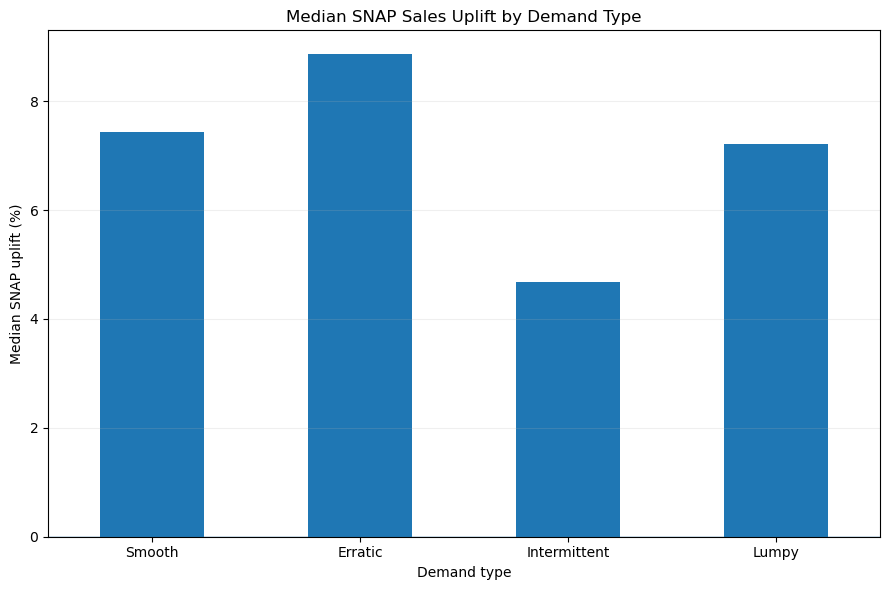

Saved: ..\outputs\figures\step13\step13_snap_uplift_by_demand_type.png


In [23]:
fig, ax = plt.subplots(figsize=(9, 6))

snap_effect_summary[
    "median_snap_uplift_pct"
].plot(
    kind="bar",
    ax=ax
)

ax.axhline(
    0,
    linewidth=1
)

ax.set_xlabel("Demand type")
ax.set_ylabel("Median SNAP uplift (%)")
ax.set_title("Median SNAP Sales Uplift by Demand Type")

ax.set_xticklabels(
    [
        demand_type.title()
        for demand_type in demand_type_order
    ],
    rotation=0
)

ax.grid(
    axis="y",
    alpha=0.2
)

figure_file = (
    figures_path
    / "step13_snap_uplift_by_demand_type.png"
)

fig.tight_layout()

fig.savefig(
    figure_file,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:", figure_file)

**Figure 13.6:** Median series-level SNAP uplift by demand type.

In [24]:
event_series_effect = (
    selected_m5_data
    .groupby(
        ["id", "demand_type", "has_event"],
        observed=True
    )["sales"]
    .mean()
    .unstack("has_event")
    .reindex(columns=[False, True])
    .rename(
        columns={
            False: "mean_non_event_sales",
            True: "mean_event_sales"
        }
    )
    .reset_index()
)

event_series_effect["event_uplift_pct"] = np.where(
    event_series_effect["mean_non_event_sales"] > 0,
    (
        event_series_effect["mean_event_sales"]
        / event_series_effect["mean_non_event_sales"]
        - 1
    )
    * 100,
    np.nan
)

event_effect_summary = (
    event_series_effect
    .groupby("demand_type", observed=True)
    .agg(
        series_count=("id", "count"),
        mean_non_event_sales=(
            "mean_non_event_sales",
            "mean"
        ),
        mean_event_sales=(
            "mean_event_sales",
            "mean"
        ),
        mean_event_uplift_pct=(
            "event_uplift_pct",
            "mean"
        ),
        median_event_uplift_pct=(
            "event_uplift_pct",
            "median"
        ),
        positive_uplift_series_pct=(
            "event_uplift_pct",
            lambda values: (values > 0).mean() * 100
        )
    )
    .reindex(demand_type_order)
    .round(3)
)

event_effect_summary

,series_count,mean_non_event_sales,mean_event_sales,mean_event_uplift_pct,median_event_uplift_pct,positive_uplift_series_pct
demand_type,,,,,,
smooth,200,6.411,6.240,-3.183,-3.707,31.5
erratic,200,6.745,6.481,-2.937,-3.150,32.5
intermittent,200,0.669,0.623,-6.598,-7.066,29.5
lumpy,200,1.475,1.401,-4.257,-5.732,36.5


In [25]:
event_effect_summary.to_csv(
    tables_path
    / "step13_event_effect_by_demand_type.csv"
)

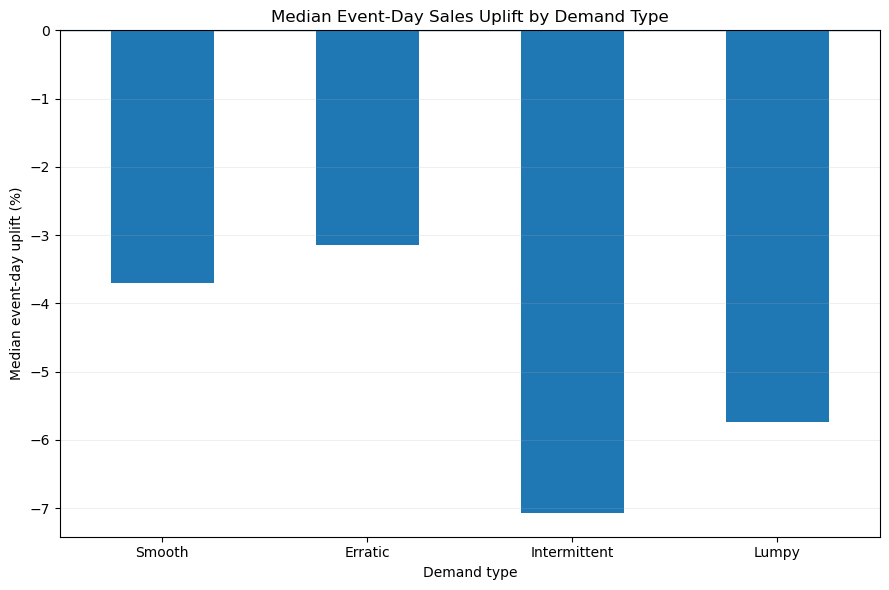

Saved: ..\outputs\figures\step13\step13_event_uplift_by_demand_type.png


In [26]:
fig, ax = plt.subplots(figsize=(9, 6))

event_effect_summary[
    "median_event_uplift_pct"
].plot(
    kind="bar",
    ax=ax
)

ax.axhline(
    0,
    linewidth=1
)

ax.set_xlabel("Demand type")
ax.set_ylabel("Median event-day uplift (%)")
ax.set_title("Median Event-Day Sales Uplift by Demand Type")

ax.set_xticklabels(
    [
        demand_type.title()
        for demand_type in demand_type_order
    ],
    rotation=0
)

ax.grid(
    axis="y",
    alpha=0.2
)

figure_file = (
    figures_path
    / "step13_event_uplift_by_demand_type.png"
)

fig.tight_layout()

fig.savefig(
    figure_file,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:", figure_file)

**Figure 13.7:** Median series-level event-day uplift by demand type.

In [27]:
series_price_coverage = (
    selected_m5_data
    .groupby(
        ["id", "demand_type"],
        observed=True
    )
    .agg(
        price_coverage_pct=(
            "sell_price",
            lambda values: values.notna().mean() * 100
        ),
        mean_observed_price=("sell_price", "mean"),
        median_observed_price=("sell_price", "median")
    )
    .reset_index()
)

weekly_price = (
    selected_m5_data[
        [
            "id",
            "demand_type",
            "wm_yr_wk",
            "sell_price"
        ]
    ]
    .drop_duplicates(
        subset=[
            "id",
            "wm_yr_wk"
        ]
    )
    .sort_values(
        ["id", "wm_yr_wk"]
    )
)

weekly_price["previous_price"] = (
    weekly_price
    .groupby("id", observed=True)["sell_price"]
    .shift(1)
)

weekly_price["valid_transition"] = (
    weekly_price["sell_price"].notna()
    & weekly_price["previous_price"].notna()
)

weekly_price["price_changed"] = (
    weekly_price["valid_transition"]
    & (
        weekly_price["sell_price"]
        != weekly_price["previous_price"]
    )
)

series_price_changes = (
    weekly_price
    .groupby(
        ["id", "demand_type"],
        observed=True
    )
    .agg(
        valid_price_transitions=(
            "valid_transition",
            "sum"
        ),
        price_changes=(
            "price_changed",
            "sum"
        )
    )
    .reset_index()
)

series_price_changes["price_change_rate_pct"] = np.where(
    series_price_changes["valid_price_transitions"] > 0,
    (
        series_price_changes["price_changes"]
        / series_price_changes["valid_price_transitions"]
        * 100
    ),
    np.nan
)

series_price_profile = series_price_coverage.merge(
    series_price_changes,
    on=["id", "demand_type"],
    how="left",
    validate="one_to_one"
)

price_summary = (
    series_price_profile
    .groupby("demand_type", observed=True)
    .agg(
        series_count=("id", "count"),
        mean_price_coverage_pct=(
            "price_coverage_pct",
            "mean"
        ),
        median_price_coverage_pct=(
            "price_coverage_pct",
            "median"
        ),
        mean_observed_price=(
            "mean_observed_price",
            "mean"
        ),
        median_observed_price=(
            "median_observed_price",
            "median"
        ),
        mean_price_change_rate_pct=(
            "price_change_rate_pct",
            "mean"
        ),
        median_price_change_rate_pct=(
            "price_change_rate_pct",
            "median"
        )
    )
    .reindex(demand_type_order)
    .round(3)
)

price_summary

,series_count,mean_price_coverage_pct,median_price_coverage_pct,mean_observed_price,median_observed_price,mean_price_change_rate_pct,median_price_change_rate_pct
demand_type,,,,,,,
smooth,200,99.358,100.000,3.341,2.730,1.171,0.722
erratic,200,99.601,100.000,1.831,1.000,1.443,0.722
intermittent,200,79.258,90.443,5.610,4.375,0.943,0.721
lumpy,200,81.110,96.394,2.466,1.980,1.393,0.897


In [29]:
price_summary.to_csv(
    tables_path
    / "step13_price_behaviour_by_demand_type.csv"
)

C:\Users\gamec\AppData\Local\Temp\ipykernel_40472\1826458326.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(


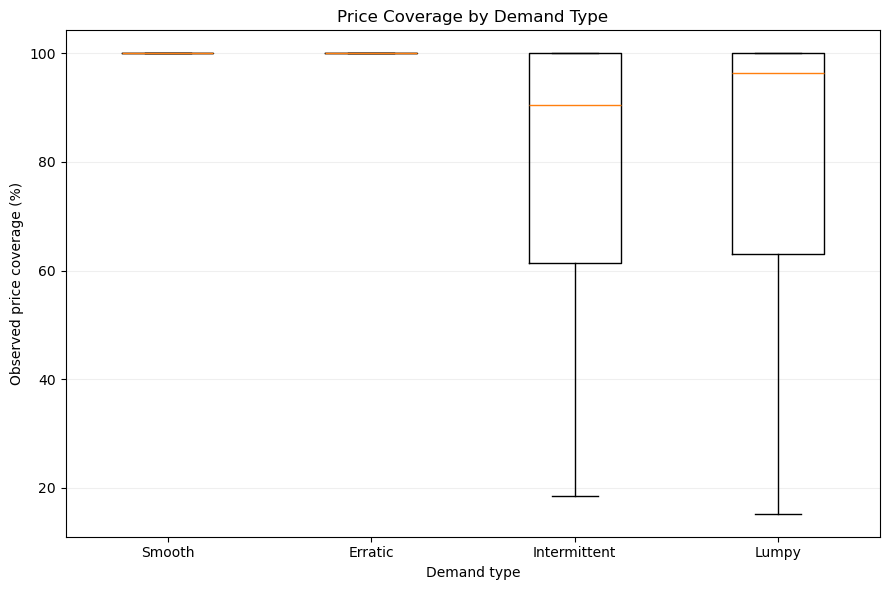

Saved: ..\outputs\figures\step13\step13_price_coverage_by_demand_type.png


In [30]:
price_coverage_plot_data = [
    series_price_profile.loc[
        series_price_profile["demand_type"] == demand_type,
        "price_coverage_pct"
    ].to_numpy()
    for demand_type in demand_type_order
]

fig, ax = plt.subplots(figsize=(9, 6))

ax.boxplot(
    price_coverage_plot_data,
    labels=[
        demand_type.title()
        for demand_type in demand_type_order
    ],
    showfliers=False
)

ax.set_xlabel("Demand type")
ax.set_ylabel("Observed price coverage (%)")
ax.set_title("Price Coverage by Demand Type")

ax.grid(
    axis="y",
    alpha=0.2
)

figure_file = (
    figures_path
    / "step13_price_coverage_by_demand_type.png"
)

fig.tight_layout()

fig.savefig(
    figure_file,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:", figure_file)

**Figure 13.8:** Observed price coverage across demand types.

In [31]:
step13_master_summary = pd.DataFrame(
    index=demand_type_order
)

step13_master_summary.index.name = "demand_type"

step13_master_summary[
    "series_count"
] = demand_type_profile["series_count"]

step13_master_summary[
    "mean_ADI"
] = demand_type_profile["mean_ADI"]

step13_master_summary[
    "mean_CV2"
] = demand_type_profile["mean_CV2"]

step13_master_summary[
    "mean_zero_rate"
] = demand_type_profile["mean_zero_rate"]

step13_master_summary[
    "median_total_sales_per_series"
] = sales_volume_summary[
    "median_total_sales_per_series"
]

step13_master_summary[
    "median_non_zero_demand"
] = sales_volume_summary[
    "median_non_zero_demand"
]

step13_master_summary[
    "median_snap_uplift_pct"
] = snap_effect_summary[
    "median_snap_uplift_pct"
]

step13_master_summary[
    "median_event_uplift_pct"
] = event_effect_summary[
    "median_event_uplift_pct"
]

step13_master_summary[
    "mean_price_coverage_pct"
] = price_summary[
    "mean_price_coverage_pct"
]

step13_master_summary[
    "median_price_change_rate_pct"
] = price_summary[
    "median_price_change_rate_pct"
]

step13_master_summary = (
    step13_master_summary
    .round(3)
)

step13_master_summary

,series_count,mean_ADI,mean_CV2,mean_zero_rate,median_total_sales_per_series,median_non_zero_demand,median_snap_uplift_pct,median_event_uplift_pct,mean_price_coverage_pct,median_price_change_rate_pct
demand_type,,,,,,,,,,
smooth,200,1.176,0.376,14.382,7399.0,4.453,7.436,-3.707,99.358,0.722
erratic,200,1.207,0.728,16.827,10928.5,6.809,8.858,-3.150,99.601,0.722
intermittent,200,7.234,0.286,72.436,673.5,1.476,4.679,-7.066,79.258,0.721
lumpy,200,4.165,0.721,59.889,1977.5,2.463,7.220,-5.732,81.110,0.897


In [32]:
step13_master_summary.to_csv(
    tables_path
    / "step13_master_summary_by_demand_type.csv"
)

In [33]:
expected_step13_figures = [
    "step13_adi_cv2_classification.png",
    "step13_zero_rate_by_demand_type.png",
    "step13_total_sales_by_demand_type.png",
    "step13_category_mix_by_demand_type.png",
    "step13_store_mix_by_demand_type.png",
    "step13_snap_uplift_by_demand_type.png",
    "step13_event_uplift_by_demand_type.png",
    "step13_price_coverage_by_demand_type.png"
]

expected_step13_tables = [
    "step13_demand_type_profile.csv",
    "step13_sales_volume_by_demand_type.csv",
    "step13_category_counts_by_demand_type.csv",
    "step13_category_percentages_by_demand_type.csv",
    "step13_store_counts_by_demand_type.csv",
    "step13_store_percentages_by_demand_type.csv",
    "step13_snap_effect_by_demand_type.csv",
    "step13_event_effect_by_demand_type.csv",
    "step13_price_behaviour_by_demand_type.csv",
    "step13_master_summary_by_demand_type.csv"
]

step13_output_check = []

for filename in expected_step13_figures:
    file_path = figures_path / filename
    
    step13_output_check.append({
        "output_type": "figure",
        "filename": filename,
        "exists": file_path.exists(),
        "size_kb": (
            round(file_path.stat().st_size / 1024, 2)
            if file_path.exists()
            else None
        )
    })

for filename in expected_step13_tables:
    file_path = tables_path / filename
    
    step13_output_check.append({
        "output_type": "table",
        "filename": filename,
        "exists": file_path.exists(),
        "size_kb": (
            round(file_path.stat().st_size / 1024, 2)
            if file_path.exists()
            else None
        )
    })

step13_output_check = pd.DataFrame(
    step13_output_check
)

step13_output_check

,output_type,filename,exists,size_kb
0,figure,step13_adi_cv2_classification.png,True,689.83
1,figure,step13_zero_rate_by_demand_type.png,True,85.39
2,figure,step13_total_sales_by_demand_type.png,True,89.30
3,figure,step13_category_mix_by_demand_type.png,True,106.13
4,figure,step13_store_mix_by_demand_type.png,True,151.09
5,figure,step13_snap_uplift_by_demand_type.png,True,80.39
6,figure,step13_event_uplift_by_demand_type.png,True,86.12
7,figure,step13_price_coverage_by_demand_type.png,True,91.02
8,table,step13_demand_type_profile.csv,True,0.49
9,table,step13_sales_volume_by_demand_type.csv,True,0.43


In [34]:
print(
    "All Step 13 outputs saved:",
    step13_output_check["exists"].all()
)

print(
    "Number of figures:",
    (
        step13_output_check["output_type"]
        == "figure"
    ).sum()
)

print(
    "Number of tables:",
    (
        step13_output_check["output_type"]
        == "table"
    ).sum()
)

All Step 13 outputs saved: True
Number of figures: 8
Number of tables: 10


In [35]:
step13_output_check.to_csv(
    tables_path
    / "step13_output_validation.csv",
    index=False
)

## Step 13 Interpretation

### 13.1 Data validation

The demand-type EDA used 1,552,800 item-store-day observations from 800 selected series. Each of the 800 series contained exactly 1,941 daily observations covering 29 January 2011 to 22 May 2016.

The dataset contained 0 duplicate item-date rows and 0 missing demand-type values. Each demand type contained 200 series, giving smooth, erratic, intermittent, and lumpy demand an equal 25.0% share of the modelling subset.

This balanced structure supports direct comparison between the 4 demand types, but it does not reproduce the original M5 population, where intermittent demand accounted for 75.681% of the 30,490 series.

### 13.2 Sparsity and demand occurrence

The 4 demand types showed clear differences in how often sales occurred. Smooth series had a mean ADI of 1.176 and a mean zero-sales rate of 14.382%, while erratic series had a mean ADI of 1.207 and a mean zero-sales rate of 16.827%.

Intermittent series had the highest mean ADI at 7.234, meaning that non-zero sales occurred approximately once every 7.234 days. Their mean zero-sales rate was 72.436%, compared with 59.889% for lumpy series.

Lumpy series had a mean ADI of 4.165, meaning that non-zero sales occurred approximately once every 4.165 days. The difference between intermittent and lumpy demand was therefore not only the frequency of sales but also the variability of non-zero demand sizes.

Mean CV² was 0.286 for intermittent series and 0.376 for smooth series, both below the classification threshold of 0.49. Mean CV² increased to 0.728 for erratic demand and 0.721 for lumpy demand, confirming that these 2 groups had greater variation in non-zero sales quantities.

### 13.3 Sales volume by demand type

Erratic demand had the highest median total sales per series at 10,928.5 units, followed by smooth demand at 7,399.0 units. Lumpy demand had median total sales of 1,977.5 units, while intermittent demand had the lowest median at 673.5 units.

The median daily sales level was 5.630 units for erratic demand and 3.812 units for smooth demand. This decreased to 1.019 units for lumpy demand and 0.347 units for intermittent demand.

When sales occurred, erratic series recorded the highest median non-zero demand at 6.809 units. Smooth series recorded 4.453 units, lumpy series recorded 2.463 units, and intermittent series recorded 1.476 units.

These values show that intermittent demand was sparse and generally low-volume, while lumpy demand combined periods of zero sales with larger and more variable non-zero quantities.

### 13.4 Category composition

FOODS represented 67.0% of smooth series, 70.5% of erratic series, and 64.0% of lumpy series. In comparison, FOODS represented only 40.0% of intermittent series.

Intermittent demand had the most balanced category composition, with 40.0% FOODS, 39.0% HOUSEHOLD, and 21.0% HOBBIES. Smooth demand contained only 7.0% HOBBIES series, while lumpy demand contained 20.0%.

The category differences mean that part of the observed variation in sales volume and price may reflect product composition. For example, intermittent demand contained 39.0% HOUSEHOLD series, while lumpy demand contained only 16.0%.

Category composition will therefore be considered when interpreting model errors and SHAP feature importance across the 4 demand types.

### 13.5 Store composition

All 10 stores were represented in each demand type. Each store contributed between 12 and 42 smooth series, between 10 and 34 erratic series, between 18 and 22 intermittent series, and between 15 and 24 lumpy series.

CA_3 had the largest share of smooth demand at 21.0% and the largest share of erratic demand at 17.0%. CA_4 had the smallest erratic share at 5.0%, while WI_2 had the smallest smooth share at 6.0%.

The intermittent group had the most even store distribution, with every store accounting for between 9.0% and 11.0% of its 200 selected series.

The presence of all 10 stores in each demand type reduces the risk that later model comparisons will be driven by a single store.

### 13.6 SNAP effect

Median sales were higher on SNAP-active days for all 4 demand types. Erratic demand had the largest median SNAP uplift at 8.858%, followed by smooth demand at 7.436% and lumpy demand at 7.220%.

Intermittent demand had the smallest median SNAP uplift at 4.679%. A positive uplift was recorded for 70.5% of intermittent series, compared with 88.5% of smooth, 86.5% of erratic, and 76.0% of lumpy series.

The mean SNAP uplift was 14.056% for lumpy demand and 14.005% for erratic demand, while their median uplifts were 7.220% and 8.858%. The gap between the mean and median suggests that a smaller number of series recorded large positive changes.

These results support including SNAP as a forecasting feature, but the percentages are descriptive rather than causal because SNAP timing, category composition, state, and calendar effects were not controlled in Step 13.

### 13.7 Event-day effect

Median sales were lower on event days for all 4 demand types. Intermittent demand had the largest median decline at −7.066%, followed by lumpy demand at −5.732%.

Smooth demand recorded a median event-day change of −3.707%, while erratic demand recorded −3.150%. Only 29.5% of intermittent series and 31.5% of smooth series recorded higher average sales on event days.

The share of series with a positive event effect remained below 37.0% for every demand type. Lumpy demand had the highest positive share at 36.5%, while intermittent demand had the lowest at 29.5%.

The negative averages do not mean that events reduce sales. The M5 event variables combine different cultural, national, religious, and sporting events, and their effects may differ by product, category, state, and date.

Event variables should therefore remain in the forecasting model, where their value will be tested through the demand-type ablation study rather than judged from the average event-day comparison alone.

### 13.8 Price behaviour

Price coverage differed sharply across demand types. Smooth series had mean price coverage of 99.358%, while erratic series had coverage of 99.601%.

Mean price coverage fell to 79.258% for intermittent demand and 81.110% for lumpy demand. This produced a gap of 20.343 percentage points between erratic and intermittent series.

The lower price coverage for intermittent and lumpy demand may reflect later product introductions or periods before products were actively listed. Missing prices will not be backward-filled because that would use future information.

Intermittent series had the highest mean observed price at 5.610, compared with 3.341 for smooth, 2.466 for lumpy, and 1.831 for erratic series. These differences must be read alongside the category mix because intermittent demand contained 39.0% HOUSEHOLD series.

Median weekly price-change rates were low across all 4 demand types. Smooth and erratic demand both recorded approximately 0.722%, intermittent demand recorded 0.721%, and lumpy demand recorded 0.897%.

Price changes were therefore infrequent, but the price feature group may still be useful for specific products or dates. Its predictive value will be tested by removing the complete price feature group during the later ablation study.

### 13.9 Implications for the modelling stage

The Step 13 results confirm that the 4 demand groups differ in frequency, variability, volume, category composition, SNAP response, event response, and price coverage.

Intermittent demand had the highest mean zero-sales rate at 72.436% and the lowest median total sales at 673.5 units. Erratic demand had a mean zero-sales rate of only 16.827% but the highest median total sales at 10,928.5 units.

These differences support evaluating the seasonal naive baseline and XGBoost separately for each demand type. A single score across the balanced 800-series subset could hide weak performance on the 200 intermittent or 200 lumpy series.

Step 13 does not test whether XGBoost or the seasonal naive model is better. Hypotheses H1–H4 will only be assessed after walk-forward forecasting results are available from Steps 15, 16, 18, and 21.


### Surprise Log

The main surprise in Step 13 was that event-day sales were lower for all 4 demand types. The median event-day change ranged from −3.150% for erratic demand to −7.066% for intermittent demand, and fewer than 37.0% of series in any group recorded a positive event effect.

This result does not show that events cause lower sales. It shows that treating all event types as one group can hide differences between individual events, categories, states, and products. Event features will remain in the model and their forecasting value will be tested through ablation.
